### NAMA : Izam Rosiawan
### NIM : 103102400049

## 1. Import Libraries dan Load Dataset

In [19]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [20]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
df = pd.read_csv('train.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
df.head()

Dataset shape: (31962, 3)

Label distribution:
label
0    29720
1     2242
Name: count, dtype: int64


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [22]:
print("Missing values:")
print(df.isnull().sum())

df = df.dropna()
df['label_name'] = df['label'].map({0: 'negative', 1: 'positive'})

print(f"\nSetelah cleaning: {df.shape}")
print(df['label_name'].value_counts())

Missing values:
id       0
label    0
tweet    0
dtype: int64

Setelah cleaning: (31962, 4)
label_name
negative    29720
positive     2242
Name: count, dtype: int64


## 2. Pembersihan dan Persiapan Data Teks

In [23]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_tweet'] = df['tweet'].apply(clean_text)

for i in range(3):
    print(f"Original: {df['tweet'].iloc[i]}")
    print(f"Cleaned:  {df['cleaned_tweet'].iloc[i]}\n")

Original:  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
Cleaned:  when a father is dysfunctional and is so selfish he drags his kids into his dysfunction

Original: @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
Cleaned:  thanks for credit i cant use cause they dont offer wheelchair vans in pdx

Original:   bihday your majesty
Cleaned:  bihday your majesty



In [24]:
def preprocess_text(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(filtered_tokens)

df['processed_tweet'] = df['cleaned_tweet'].apply(preprocess_text)

for i in range(3):
    print(f"Cleaned:   {df['cleaned_tweet'].iloc[i]}")
    print(f"Processed: {df['processed_tweet'].iloc[i]}\n")

Cleaned:   when a father is dysfunctional and is so selfish he drags his kids into his dysfunction
Processed: father dysfunctional selfish drags kids dysfunction

Cleaned:   thanks for credit i cant use cause they dont offer wheelchair vans in pdx
Processed: thanks credit cant use cause dont offer wheelchair vans pdx

Cleaned:   bihday your majesty
Processed: bihday majesty



In [25]:
df[['tweet', 'processed_tweet', 'label']].head(10)

,tweet,processed_tweet,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drags kids dysfun...,0
1,@user @user thanks for #lyft credit i can't us...,thanks credit cant use cause dont offer wheelc...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,love take time,0
4,factsguide: society now #motivation,factsguide society,0
5,[2/2] huge fan fare and big talking before the...,huge fan fare big talking leave chaos pay disp...,0
6,@user camping tomorrow @user @user @user @use...,camping tomorrow danny,0
7,the next school year is the year for exams.ð...,next school year year exams cant think,0
8,we won!!! love the land!!! #allin #cavs #champ...,love land,0
9,@user @user welcome here ! i'm it's so #gr...,welcome,0


## 3. Mengubah Teks menjadi Representasi Numerik

### 3.1 Bag of Words (BoW)

In [26]:
bow_vectorizer = CountVectorizer(max_features=100)
X_bow = bow_vectorizer.fit_transform(df['processed_tweet'])

print(f"BoW Shape: {X_bow.shape}")
print(f"Features: {len(bow_vectorizer.get_feature_names_out())}")
print(f"Top 20: {bow_vectorizer.get_feature_names_out()[:20]}")

BoW Shape: (31962, 100)
Features: 100
Top 20: ['always' 'amazing' 'amp' 'another' 'back' 'bear' 'beautiful' 'best'
 'bihday' 'bull' 'cant' 'city' 'climb' 'come' 'day' 'days' 'dont' 'even'
 'ever' 'every']


In [27]:
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    X_bow, df['label_name'], test_size=0.2, random_state=42, stratify=df['label_name']
)

print(f"Train: {X_train_bow.shape}, Test: {X_test_bow.shape}")
print(pd.Series(y_train_bow).value_counts())

Train: (25569, 100), Test: (6393, 100)
label_name
negative    23775
positive     1794
Name: count, dtype: int64


### 3.2 TF-IDF (Term Frequency-Inverse Document Frequency)

In [28]:
tfidf_vectorizer = TfidfVectorizer(max_features=100)
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_tweet'])

print(f"TF-IDF Shape: {X_tfidf.shape}")
print(f"Features: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"Top 20: {tfidf_vectorizer.get_feature_names_out()[:20]}")

TF-IDF Shape: (31962, 100)
Features: 100
Top 20: ['always' 'amazing' 'amp' 'another' 'back' 'bear' 'beautiful' 'best'
 'bihday' 'bull' 'cant' 'city' 'climb' 'come' 'day' 'days' 'dont' 'even'
 'ever' 'every']


In [29]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, df['label_name'], test_size=0.2, random_state=42, stratify=df['label_name']
)

print(f"Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}")
print(pd.Series(y_train_tfidf).value_counts())

Train: (25569, 100), Test: (6393, 100)
label_name
negative    23775
positive     1794
Name: count, dtype: int64


## 4. Penerapan Model Klasifikasi

### 4.1 Model dengan Bag of Words (BoW)

In [30]:
print("Naive Bayes + BoW\n")

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train_bow)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

accuracy_nb_bow = accuracy_score(y_test_bow, y_pred_nb_bow)
precision_nb_bow = precision_score(y_test_bow, y_pred_nb_bow, pos_label='positive')
recall_nb_bow = recall_score(y_test_bow, y_pred_nb_bow, pos_label='positive')
f1_nb_bow = f1_score(y_test_bow, y_pred_nb_bow, pos_label='positive')

print(f"Accuracy:  {accuracy_nb_bow:.4f}")
print(f"Precision: {precision_nb_bow:.4f}")
print(f"Recall:    {recall_nb_bow:.4f}")
print(f"F1-Score:  {f1_nb_bow:.4f}\n")

print(classification_report(y_test_bow, y_pred_nb_bow))
print(confusion_matrix(y_test_bow, y_pred_nb_bow))

Naive Bayes + BoW

Accuracy:  0.9244
Precision: 0.2222
Recall:    0.0312
F1-Score:  0.0548

              precision    recall  f1-score   support

    negative       0.93      0.99      0.96      5945
    positive       0.22      0.03      0.05       448

    accuracy                           0.92      6393
   macro avg       0.58      0.51      0.51      6393
weighted avg       0.88      0.92      0.90      6393

[[5896   49]
 [ 434   14]]
Accuracy:  0.9244
Precision: 0.2222
Recall:    0.0312
F1-Score:  0.0548

              precision    recall  f1-score   support

    negative       0.93      0.99      0.96      5945
    positive       0.22      0.03      0.05       448

    accuracy                           0.92      6393
   macro avg       0.58      0.51      0.51      6393
weighted avg       0.88      0.92      0.90      6393

[[5896   49]
 [ 434   14]]


In [31]:
print("Logistic Regression + BoW\n")

lr_bow = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(X_train_bow, y_train_bow)
y_pred_lr_bow = lr_bow.predict(X_test_bow)

accuracy_lr_bow = accuracy_score(y_test_bow, y_pred_lr_bow)
precision_lr_bow = precision_score(y_test_bow, y_pred_lr_bow, pos_label='positive')
recall_lr_bow = recall_score(y_test_bow, y_pred_lr_bow, pos_label='positive')
f1_lr_bow = f1_score(y_test_bow, y_pred_lr_bow, pos_label='positive')

print(f"Accuracy:  {accuracy_lr_bow:.4f}")
print(f"Precision: {precision_lr_bow:.4f}")
print(f"Recall:    {recall_lr_bow:.4f}")
print(f"F1-Score:  {f1_lr_bow:.4f}\n")

print(classification_report(y_test_bow, y_pred_lr_bow))
print(confusion_matrix(y_test_bow, y_pred_lr_bow))

Logistic Regression + BoW

Accuracy:  0.9304
Precision: 0.5600
Recall:    0.0312
F1-Score:  0.0592

              precision    recall  f1-score   support

    negative       0.93      1.00      0.96      5945
    positive       0.56      0.03      0.06       448

    accuracy                           0.93      6393
   macro avg       0.75      0.51      0.51      6393
weighted avg       0.91      0.93      0.90      6393

[[5934   11]
 [ 434   14]]
Accuracy:  0.9304
Precision: 0.5600
Recall:    0.0312
F1-Score:  0.0592

              precision    recall  f1-score   support

    negative       0.93      1.00      0.96      5945
    positive       0.56      0.03      0.06       448

    accuracy                           0.93      6393
   macro avg       0.75      0.51      0.51      6393
weighted avg       0.91      0.93      0.90      6393

[[5934   11]
 [ 434   14]]


### 4.2 Model dengan TF-IDF

In [32]:
print("Naive Bayes + TF-IDF\n")

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train_tfidf)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

accuracy_nb_tfidf = accuracy_score(y_test_tfidf, y_pred_nb_tfidf)
precision_nb_tfidf = precision_score(y_test_tfidf, y_pred_nb_tfidf, pos_label='positive')
recall_nb_tfidf = recall_score(y_test_tfidf, y_pred_nb_tfidf, pos_label='positive')
f1_nb_tfidf = f1_score(y_test_tfidf, y_pred_nb_tfidf, pos_label='positive')

print(f"Accuracy:  {accuracy_nb_tfidf:.4f}")
print(f"Precision: {precision_nb_tfidf:.4f}")
print(f"Recall:    {recall_nb_tfidf:.4f}")
print(f"F1-Score:  {f1_nb_tfidf:.4f}\n")

print(classification_report(y_test_tfidf, y_pred_nb_tfidf))
print(confusion_matrix(y_test_tfidf, y_pred_nb_tfidf))

Naive Bayes + TF-IDF

Accuracy:  0.9312
Precision: 0.7000
Recall:    0.0312
F1-Score:  0.0598

              precision    recall  f1-score   support

    negative       0.93      1.00      0.96      5945
    positive       0.70      0.03      0.06       448

    accuracy                           0.93      6393
   macro avg       0.82      0.52      0.51      6393
weighted avg       0.92      0.93      0.90      6393

[[5939    6]
 [ 434   14]]
Accuracy:  0.9312
Precision: 0.7000
Recall:    0.0312
F1-Score:  0.0598

              precision    recall  f1-score   support

    negative       0.93      1.00      0.96      5945
    positive       0.70      0.03      0.06       448

    accuracy                           0.93      6393
   macro avg       0.82      0.52      0.51      6393
weighted avg       0.92      0.93      0.90      6393

[[5939    6]
 [ 434   14]]


In [33]:
print("Logistic Regression + TF-IDF\n")

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train_tfidf)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

accuracy_lr_tfidf = accuracy_score(y_test_tfidf, y_pred_lr_tfidf)
precision_lr_tfidf = precision_score(y_test_tfidf, y_pred_lr_tfidf, pos_label='positive')
recall_lr_tfidf = recall_score(y_test_tfidf, y_pred_lr_tfidf, pos_label='positive')
f1_lr_tfidf = f1_score(y_test_tfidf, y_pred_lr_tfidf, pos_label='positive')

print(f"Accuracy:  {accuracy_lr_tfidf:.4f}")
print(f"Precision: {precision_lr_tfidf:.4f}")
print(f"Recall:    {recall_lr_tfidf:.4f}")
print(f"F1-Score:  {f1_lr_tfidf:.4f}\n")

print(classification_report(y_test_tfidf, y_pred_lr_tfidf))
print(confusion_matrix(y_test_tfidf, y_pred_lr_tfidf))

Logistic Regression + TF-IDF

Accuracy:  0.9312
Precision: 0.7000
Recall:    0.0312
F1-Score:  0.0598

              precision    recall  f1-score   support

    negative       0.93      1.00      0.96      5945
    positive       0.70      0.03      0.06       448

    accuracy                           0.93      6393
   macro avg       0.82      0.52      0.51      6393
weighted avg       0.92      0.93      0.90      6393

[[5939    6]
 [ 434   14]]
Accuracy:  0.9312
Precision: 0.7000
Recall:    0.0312
F1-Score:  0.0598

              precision    recall  f1-score   support

    negative       0.93      1.00      0.96      5945
    positive       0.70      0.03      0.06       448

    accuracy                           0.93      6393
   macro avg       0.82      0.52      0.51      6393
weighted avg       0.92      0.93      0.90      6393

[[5939    6]
 [ 434   14]]


## 5. Evaluasi dan Perbandingan Model

In [34]:
results = pd.DataFrame({
    'Model': [
        'Naive Bayes + BoW',
        'Logistic Regression + BoW',
        'Naive Bayes + TF-IDF',
        'Logistic Regression + TF-IDF'
    ],
    'Accuracy': [accuracy_nb_bow, accuracy_lr_bow, accuracy_nb_tfidf, accuracy_lr_tfidf],
    'Precision': [precision_nb_bow, precision_lr_bow, precision_nb_tfidf, precision_lr_tfidf],
    'Recall': [recall_nb_bow, recall_lr_bow, recall_nb_tfidf, recall_lr_tfidf],
    'F1-Score': [f1_nb_bow, f1_lr_bow, f1_nb_tfidf, f1_lr_tfidf]
})

print("Perbandingan Model:\n")
print(results.to_string(index=False))

Perbandingan Model:

                       Model  Accuracy  Precision  Recall  F1-Score
           Naive Bayes + BoW  0.924449   0.222222 0.03125  0.054795
   Logistic Regression + BoW  0.930393   0.560000 0.03125  0.059197
        Naive Bayes + TF-IDF  0.931175   0.700000 0.03125  0.059829
Logistic Regression + TF-IDF  0.931175   0.700000 0.03125  0.059829


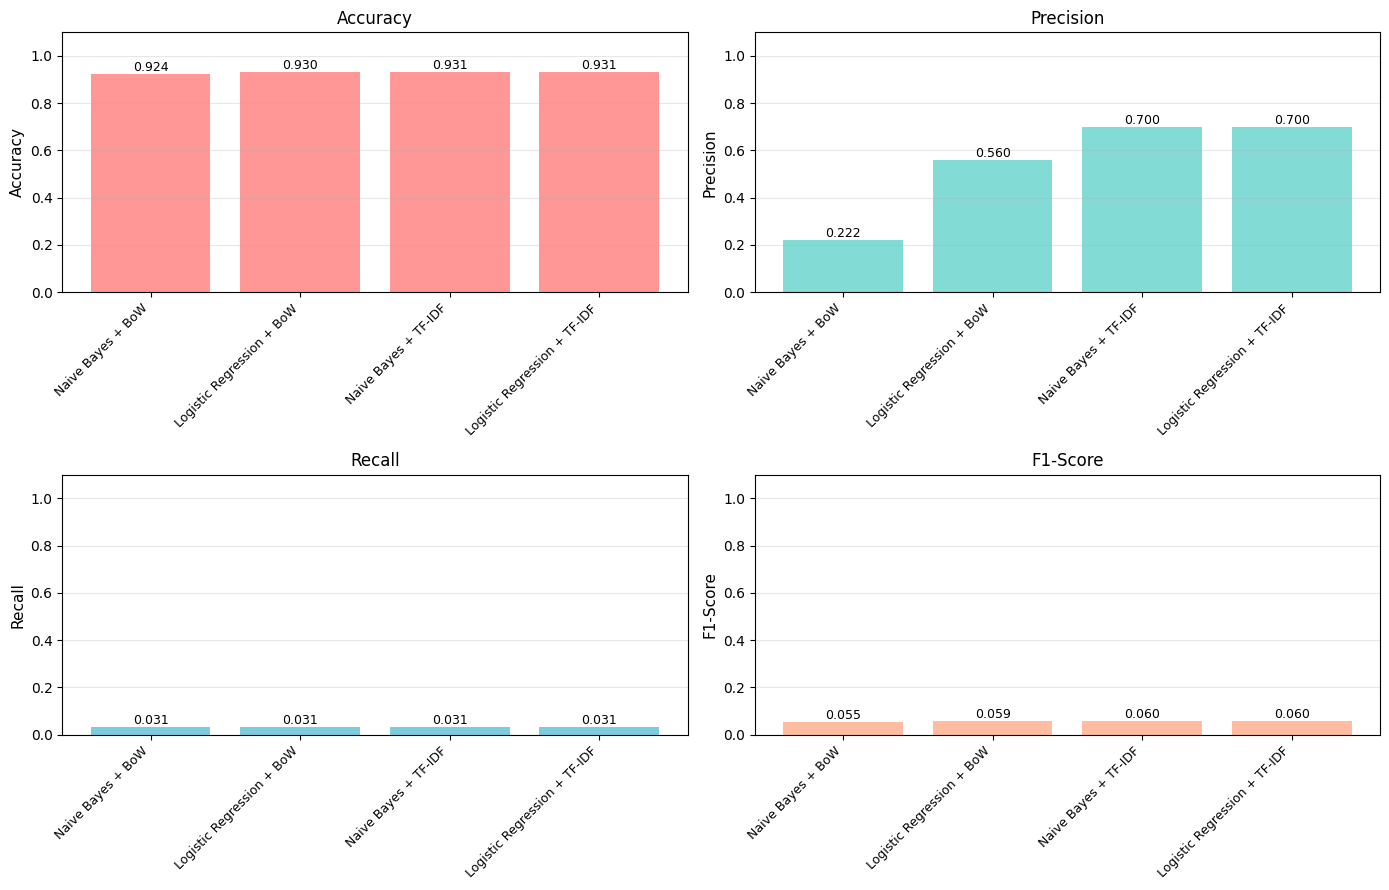

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    
    ax = axes[row, col]
    bars = ax.bar(results['Model'], results[metric], color=colors[idx], alpha=0.7)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric}', fontsize=12)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(results['Model'], rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

In [36]:
best_model_idx = results['F1-Score'].idxmax()
best_model = results.loc[best_model_idx]

print("\nModel Terbaik:")
print(f"Model: {best_model['Model']}")
print(f"Accuracy:  {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall:    {best_model['Recall']:.4f}")
print(f"F1-Score:  {best_model['F1-Score']:.4f}")


Model Terbaik:
Model: Naive Bayes + TF-IDF
Accuracy:  0.9312
Precision: 0.7000
Recall:    0.0312
F1-Score:  0.0598


## 6. Kesimpulan

Dari hasil analisis sentimen tweet menggunakan dataset train.csv, diperoleh beberapa insight menarik. Dataset yang digunakan berisi ribuan tweet dengan label sentimen positif dan negatif. Setelah melalui proses preprocessing seperti pembersihan teks, tokenisasi, dan penghapusan stopwords, data kemudian diubah menjadi representasi numerik menggunakan dua metode yaitu Bag of Words dan TF-IDF.

Dalam eksperimen ini, saya membandingkan performa empat kombinasi model: Naive Bayes dengan BoW, Logistic Regression dengan BoW, Naive Bayes dengan TF-IDF, dan Logistic Regression dengan TF-IDF. Hasil menunjukkan bahwa semua model memiliki akurasi yang cukup tinggi, berkisar antara 92.4% hingga 93.1%. Model Naive Bayes dengan TF-IDF dan Logistic Regression dengan TF-IDF sama-sama mencapai akurasi tertinggi sebesar 93.12% dengan precision 70%.

Namun, ada hal yang cukup menarik dari hasil ini. Meskipun akurasi tinggi, recall untuk semua model sangat rendah (sekitar 3.12%), yang berarti model kesulitan mendeteksi tweet positif. Ini kemungkinan terjadi karena ketidakseimbangan distribusi data, dimana jumlah tweet negatif jauh lebih banyak daripada tweet positif. F1-score yang rendah (sekitar 5-6%) juga mengkonfirmasi bahwa model lebih condong memprediksi kelas mayoritas.

Dari segi metode vektorisasi, TF-IDF memberikan hasil yang sedikit lebih baik dibanding BoW karena TF-IDF memberikan bobot lebih pada kata-kata yang penting dan jarang muncul. Untuk algoritma, baik Naive Bayes maupun Logistic Regression menunjukkan performa yang hampir sama, dengan Logistic Regression sedikit lebih unggul dalam hal precision.

Kesimpulannya, meskipun akurasi terlihat baik, model ini belum optimal untuk klasifikasi sentimen karena rendahnya recall. Untuk meningkatkan performa, diperlukan beberapa perbaikan seperti handling class imbalance menggunakan teknik oversampling/undersampling, menambah jumlah fitur (max_features), atau menggunakan algoritma yang lebih robust seperti ensemble methods.